# 第0章 写给读者的话

## 本章导读

你会调用 `torch.add`，也能运行一个模型。但同一个程序换一组输入后，为什么突然慢了？
接下来我们从一次加法出发，把“做了什么工作、数据在哪里、时间怎样测”逐步连起来。
这份 notebook 可以在没有 GPU 的 Python 环境中阅读和运行。

本章先完成一件小事：写下你想回答的性能问题，并学会区分猜测与证据。
[对应正文](../../../docs/part0-intro/chapter0/index.md)展开了全书的定位。


## 0.1 为什么写这本入门书

假设模型运行了一次，你只知道总共等了多久。这个数字还不能告诉你：慢的是哪一步、
CPU 有没有在等待、GPU 有没有在搬数据。要改进程序，我们先把大问题拆成能观察的小工作。

数组加法就是这样的起点。对于每个位置 `i`，读取 `a[i]` 和 `b[i]`，相加后写入 `c[i]`。
先在 CPU 上把规则写清楚，再考虑由多少线程一起执行。下面不是性能测试，只用于确定数学含义。


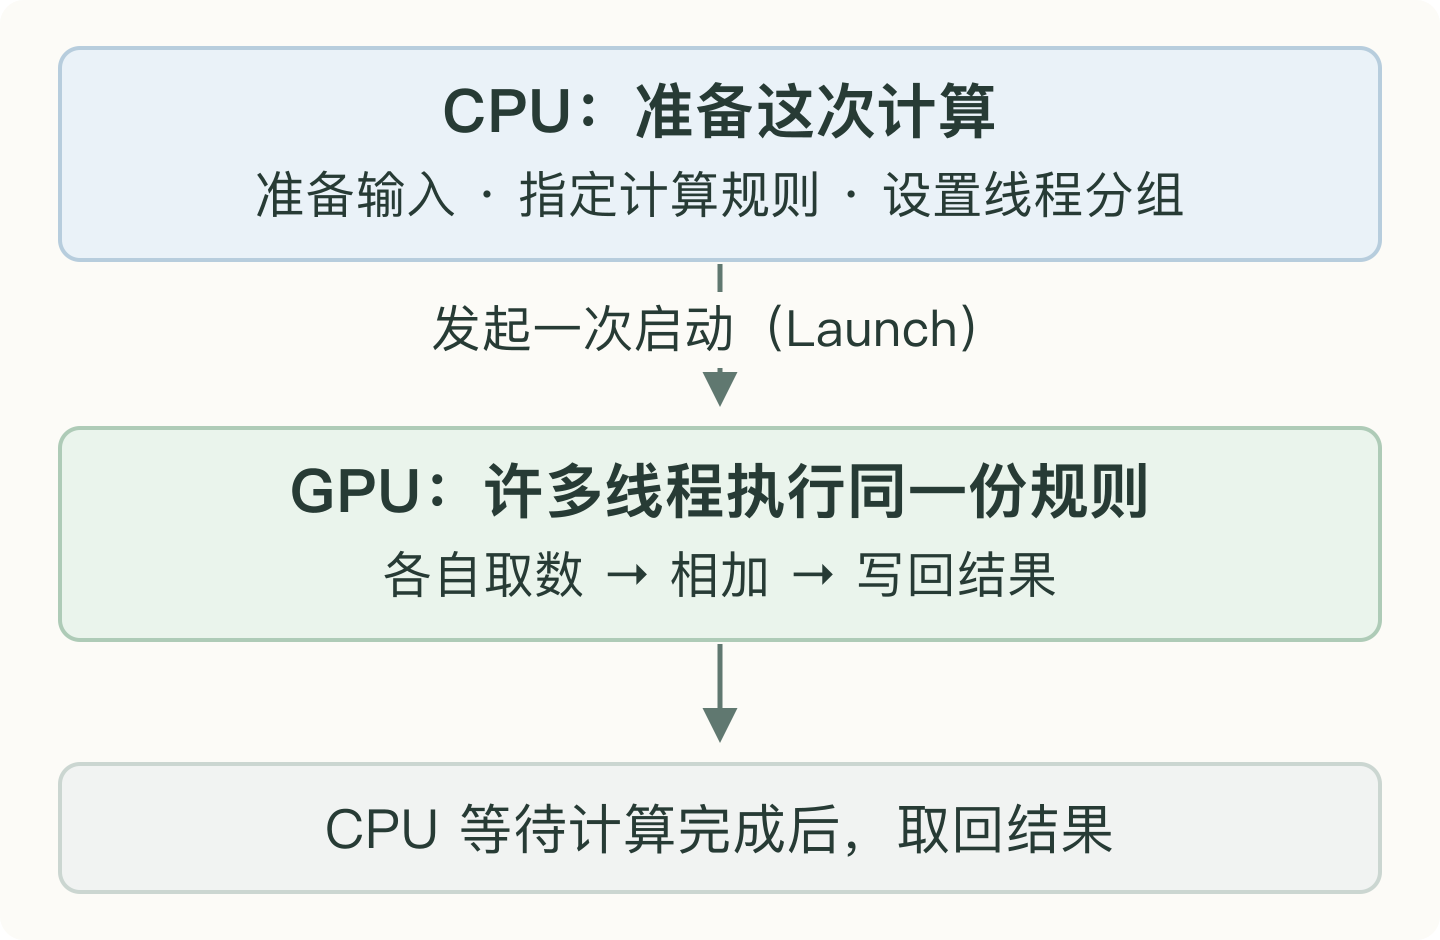

*CPU 安排任务，GPU 执行分配给它的计算；一次任务还包括数据准备与结果使用。*


In [ ]:
%run ../../common/bootstrap.py

a = [1.0, 2.0, 3.0, 4.0]
b = [10.0, 20.0, 30.0, 40.0]
c = [x + y for x, y in zip(a, b)]
assert c == [11.0, 22.0, 33.0, 44.0]
list(zip(a, b, c))


**观察**：四个输出彼此独立，计算第三个输出不需要等待第二个输出。
这为并行提供了机会，但“可以并行”并不自动等于“程序更快”：准备、提交、等待也需要时间。

### 先写下你的问题

把“我想让 GPU 快一点”改写成能验证的一句话。例如：“输入已经在 GPU 上时，
改变 block 大小，会不会改变长度固定的 FP32 向量加法时间？”下面的文本可以直接修改。


In [ ]:
my_question = "同样长度的向量加法，改变 block 大小会怎样影响时间？"
my_evidence = ["正确性检查", "同一输入规模", "重复测量", "本次硬件与软件信息"]
{"问题": my_question, "需要收集": my_evidence}


## 0.2 这本书适合谁

如果你能运行 Python、读懂数组和函数，就可以从这里开始。Linux 命令行主要用于准备环境；
HIP 的线程与指针会跟着例子逐步解释，不需要在开头背下整套术语。

| 已有基础 | 本篇先练什么 | 怎样确认学会了 |
| --- | --- | --- |
| 能写 Python，刚接触 GPU | 跟踪一个输出由哪个线程计算 | 能手算线程下标和尾部边界 |
| 经常使用 PyTorch | 分清 Tensor、kernel 和执行流 | 能解释提交后为什么还要等待 |
| 写过 CUDA 或 HIP | 重新核对当前目标和测量口径 | 不把旧设备参数当作本机结论 |
| 想做优化 Agent | 先完整走一次人工实验 | 能保存并解释一次有效与一次无效尝试 |

不用现在掌握所有列。选择最贴近自己的一行，读完第 4 章后再回来核对。


## 0.3 为什么选 AMD Radeon RX 9070 XT

本书从一张能够实际运行实验的 AMD 显卡出发，让线程分工、数据访问和性能分析始终有具体对象。
这些问题也会出现在其他设备上；变化的是工具链、执行资源以及可以测得的结果。

本篇不会让 kernel 通过硬编码 GPU 型号才能运行。先在第 1 章识别当前环境，
随后把实验结果与当次环境一起保存。当前安装基线和换卡边界集中在下一章说明。
这里先学习读出本 notebook 正在使用的 Python 环境；这个检查不要求存在 GPU。


In [ ]:
import hello_gpu as gpu

context = gpu.environment(require_gpu=False)
{key: context.get(key) for key in ("python", "torch", "hip", "gpu", "os")}


**观察**：这里选择了 `require_gpu=False`，因此不探测 GPU，设备相关信息保留为空；
空值表示尚未探测，并不表示机器没有显卡。Python 与包版本来自当前解释器，
后续 kernel 能否运行仍需下一章实际验证。


## 0.4 这本书和市面教程有什么不同

我们把每次优化看作一个可重复的小实验：明确任务，建立正确实现，测量，提出解释，改动一个因素，再测量。
失败的尝试同样有价值。如果改动没能降低时间，它至少能帮助你排除一个未经验证的假设。

| 动作 | 本轮要回答的问题 | 留下什么 |
| --- | --- | --- |
| 写规则 | 这个算子算什么？ | 参考实现与输入输出约定 |
| 测量 | 当前实现用了多久？ | 原始样本、单位、计时范围 |
| 定位 | 哪些观察支持当前解释？ | timeline、访存或资源证据 |
| 修改 | 本轮只改变什么？ | kernel 源码与参数 |
| 复查 | 更快了吗，结果还对吗？ | 同口径对照与失败记录 |

以后让 Agent 帮忙，也是让它执行这些动作。判断结果是否可信的标准不变。


In [ ]:
experiment = {
    "规则": "c[i] = a[i] + b[i]",
    "本轮变量": "block 大小",
    "保持相同": ["输入", "dtype", "预热", "重复次数", "计时范围"],
    "先检查": "所有有效位置的结果是否正确",
}
experiment


## 0.5 你将完成的事

这本 notebook 系列把学习过程留在眼前：先读一小段解释，看图找到数据和线程，运行一个短单元，
再根据输出回答问题。编译、绑定与记录这些反复出现的操作由 `hello_gpu` 包承担。
到第 1 章，你会在 `%%hip` 单元里写 kernel，随后直接用 PyTorch Tensor 调用它。

| 阶段 | 能独立完成的事 |
| --- | --- |
| 入门 | 验证环境，写出带边界检查的加法 kernel |
| Profiling | 明确计时范围，找出值得进一步分析的工作 |
| 经典算子 | 根据数据依赖设计访存与协作方式 |
| 算子 Agent | 把生成、检查、测量与选择组织成循环 |
| 真实模型 | 把局部改动放回完整任务中验证收益 |

这里没有“必须快多少倍”的预设。能解释一次变化为什么值得继续调查，就是有效进展。


## 0.6 学习路线图

先顺序完成本篇五章。前一章留下的问题，正是后一章要处理的对象。

| 接下来去哪 | 带着什么问题阅读 |
| --- | --- |
| [第 1 章：环境准备](../chapter1/chapter1.ipynb) | 我的 Python 能编译和调用 HIP 吗？ |
| [第 2 章：线程组织与执行](../chapter2/chapter2.ipynb) | 哪个线程负责哪个输出？ |
| [第 3 章：数据存储与访问](../chapter3/chapter3.ipynb) | 输入在哪里，线程怎样交接数据？ |
| [第 4 章：第一个程序 + 性能分析](../chapter4/chapter4.ipynb) | 算对以后，怎样测出有含义的时间？ |

每章都能从空白 Python 内核开始运行。修改代码后建议重启内核并“运行全部”，
检查结果是否依赖上一次留下的变量。首次编译可能需要等待，后续相同源码可以复用缓存。


## 0.7 和其他 datawhale 教程的边界

本书聚焦单卡算子、性能分析和优化过程的自动化。多卡通信与服务化可继续阅读
[hello-mlsys](https://github.com/datawhalechina/hello-mlsys)，通用智能体应用可阅读
[hello-agents](https://github.com/datawhalechina/hello-agents)。先把一次单卡实验做完整，
再扩展问题范围，会更容易知道新增的复杂性来自哪里。

### 练习

1. 把开头的加法改成逐元素乘法。哪些数据依赖保持不变？
2. 写下你自己的性能问题，并列出至少三个需要固定的条件。
3. 如果两份实现的时间不同，但一份包含输入拷贝、一份没有，你能直接宣布谁更快吗？

## 本章小结

我们已经给一次实验定义了数学规则、待验证的问题和需要保存的证据。
接下来打开[第 1 章](../chapter1/chapter1.ipynb)，把这条学习路线落实到当前 Python 和 GPU 环境。
